In [ ]:
# cell 0 — setup (auto-detects Colab vs local)
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/ma4891/ca2/"
else:
    BASE_DIR = os.path.dirname(os.path.abspath("__file__")) + "/"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pathlib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import copy, time, warnings
warnings.filterwarnings('ignore')

# device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}", f"({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else "")

# paths — all images merged into one folder with class subfolders
DATA_DIR = BASE_DIR + "data/food11/"
EXTERNAL_DIR = BASE_DIR + "external_test/"

# image config
IMG_SIZE = 150
BATCH_SIZE = 32
NUM_WORKERS = 2

# split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
SEED = 42

print(f"Running {'on Colab' if IN_COLAB else 'locally'}")
print(f"Data dir: {DATA_DIR}")
print(f"Split: {TRAIN_RATIO:.0%} train / {VAL_RATIO:.0%} val / {TEST_RATIO:.0%} test")

In [51]:
# cell 2 — explore dataset: count total images per class

class_counts = {}
p = pathlib.Path(DATA_DIR)
for cls_dir in sorted(p.iterdir()):
    if cls_dir.is_dir():
        n = len(list(cls_dir.glob("*")))
        class_counts[cls_dir.name] = n

print(f"{'='*40}")
print(f"  ALL DATA")
print(f"{'='*40}")
total = 0
for cls, n in sorted(class_counts.items()):
    print(f"  {cls:20s}: {n:5d} images")
    total += n
print(f"  {'TOTAL':20s}: {total:5d} images")

CLASS_NAMES = sorted(class_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nDetected {NUM_CLASSES} classes: {CLASS_NAMES}")

  ALL DATA
  Bread               :  1724 images
  Dairy product       :   721 images
  Dessert             :  2500 images
  Egg                 :  1648 images
  Fried food          :  1461 images
  Meat                :  2206 images
  Noodles-Pasta       :   734 images
  Rice                :   472 images
  Seafood             :  1505 images
  Soup                :  2500 images
  Vegetable-Fruit     :  1172 images
  TOTAL               : 16643 images

Detected 11 classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']


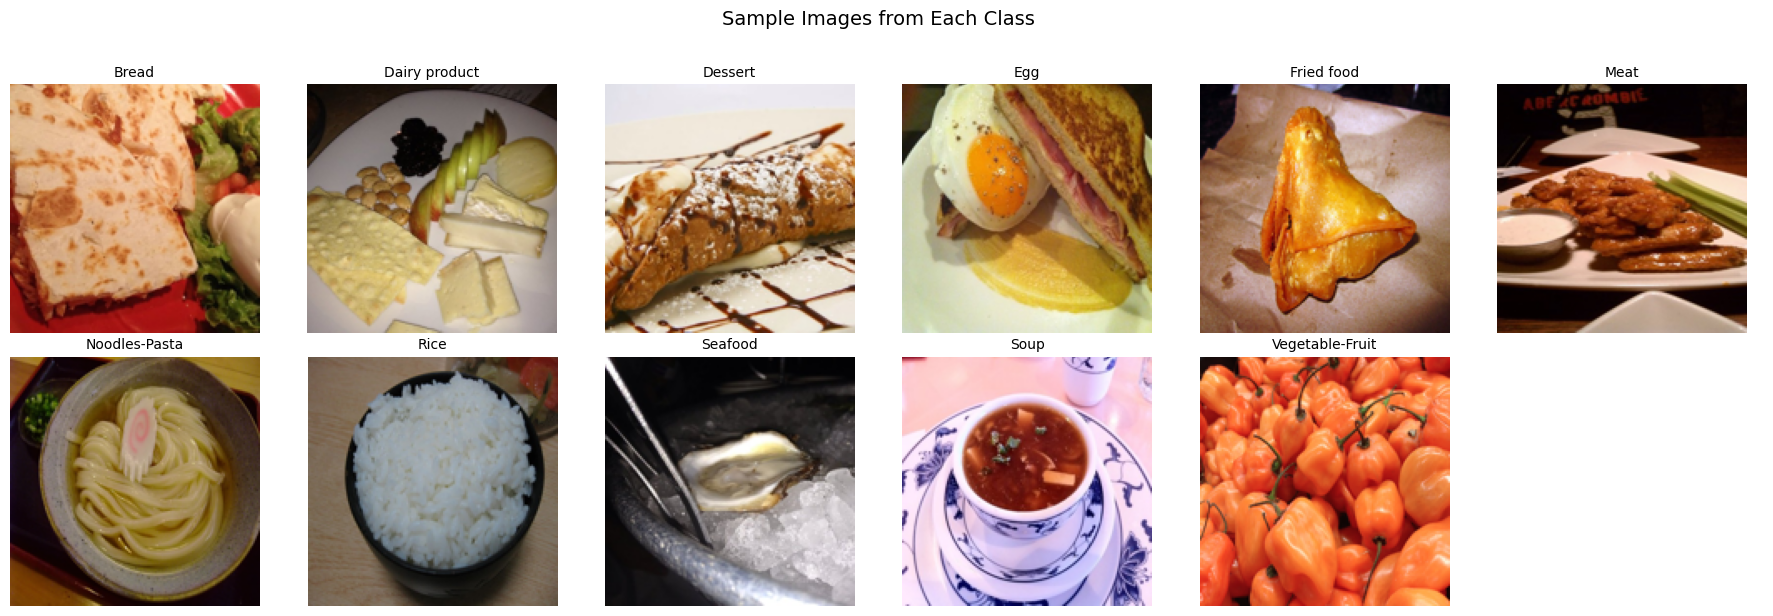

In [52]:
# cell 3 — display sample images from each class

fig, axes = plt.subplots(2, min(NUM_CLASSES, 6), figsize=(18, 6))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES[:12]):
    cls_path = pathlib.Path(DATA_DIR) / cls
    if cls_path.exists():
        img_files = list(cls_path.glob("*"))
        if img_files:
            img = Image.open(str(img_files[0])).resize((IMG_SIZE, IMG_SIZE))
            axes[i].imshow(img)
            axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Images from Each Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [53]:
# cell 4 — load all data + train/val/test split in code (NO augmentation)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# load from single directory (class subfolders)
all_dataset = datasets.ImageFolder(DATA_DIR, transform=transform_base)
print(f"Total images: {len(all_dataset)}")

# split 70/15/15
total = len(all_dataset)
train_n = int(TRAIN_RATIO * total)
val_n   = int(VAL_RATIO * total)
test_n  = total - train_n - val_n

train_dataset, val_dataset, test_dataset = random_split(
    all_dataset, [train_n, val_n, test_n],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader_base = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Batches — Train: {len(train_loader_base)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Total images: 16643
Train: 11650 | Val: 2496 | Test: 2497
Batches — Train: 365 | Val: 78 | Test: 79


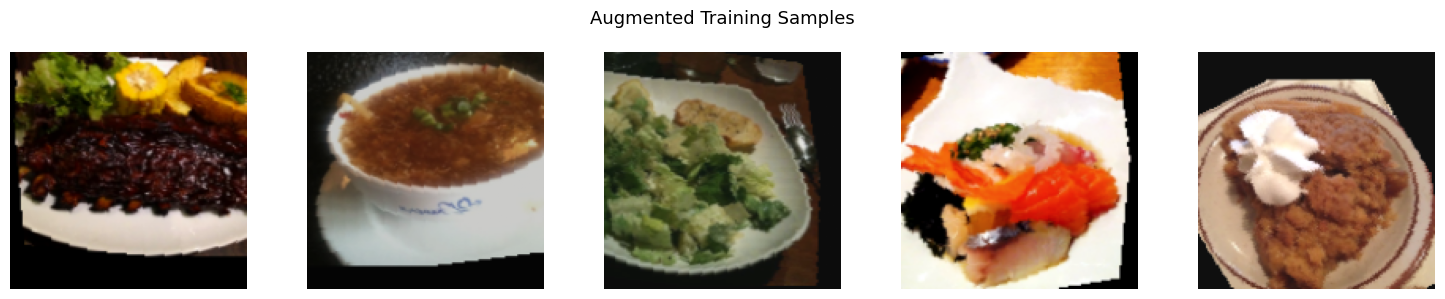

Augmented train loader: 11650 images, 365 batches


In [54]:
# cell 5 — augmented data loader (same split, different transforms on train)

transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# reload all data with augmented transform, then take the SAME train indices
all_dataset_aug = datasets.ImageFolder(DATA_DIR, transform=transform_aug)

# use the same split indices from cell 4
train_dataset_aug = Subset(all_dataset_aug, train_dataset.indices)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

# visualise augmented samples
def denormalize(tensor, mean=MEAN, std=STD):
    t = tensor.clone()
    for i in range(3):
        t[i] = t[i] * std[i] + mean[i]
    return t.clamp(0, 1)

sample_batch, _ = next(iter(train_loader_aug))
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = denormalize(sample_batch[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis("off")
plt.suptitle("Augmented Training Samples", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Augmented train loader: {len(train_dataset_aug)} images, {len(train_loader_aug)} batches")

In [55]:
# cell 7 — build custom CNN

class FoodCNN(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        # block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        # block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        # block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3))
        # block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3))
        # classifier head — 150/2/2/2/2 = 9, so flatten = 256*9*9
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 9 * 9, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

cnn_model = FoodCNN(NUM_CLASSES).to(DEVICE)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"\nTotal params: {total_params:,}  |  Trainable: {trainable_params:,}")

FoodCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momen

In [ ]:
# cell 8 — training + evaluation helper functions

EPOCHS = 30

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=0.001, patience=7, device=DEVICE, save_path=None):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, min_lr=1e-6)

    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    best_val_acc = 0.0
    best_weights = None
    wait = 0

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        dt = time.time() - t0
        lr_msg = f" ** LR reduced to {new_lr:.1e}" if new_lr < old_lr else ""
        print(f"Epoch {epoch+1:2d}/{epochs} — {dt:.0f}s — "
              f"loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f} | "
              f"lr: {new_lr:.1e}{lr_msg}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            wait = 0
            if save_path:
                torch.save(best_weights, save_path)
                print(f"  >> Saved best model ({val_acc:.4f}) to {save_path}")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1} (best val_acc: {best_val_acc:.4f})")
                break

    if best_weights:
        model.load_state_dict(best_weights)
    return history

print("Training helpers defined.")

In [ ]:
# cell 9 — train custom CNN (no augmentation baseline)
# SKIP: loading pre-trained weights from cell 9b instead
# cnn_history = train_model(cnn_model, train_loader_base, val_loader, epochs=EPOCHS, lr=0.001)
# torch.save(cnn_model.state_dict(), MODEL_DIR + "cnn_model.pth"); print("Saved cnn_model.pth")

In [58]:
# cell 9b — save / load custom CNN weights

MODEL_DIR = BASE_DIR + "models/"
os.makedirs(MODEL_DIR, exist_ok=True)

# save
#torch.save(cnn_model.state_dict(), MODEL_DIR + "cnn_model.pth")
#print(f"Saved: {MODEL_DIR}cnn_model.pth")

# to load later (uncomment and run instead of retraining):
cnn_model = FoodCNN(NUM_CLASSES).to(DEVICE)
cnn_model.load_state_dict(torch.load(MODEL_DIR + "cnn_model.pth", map_location=DEVICE))
cnn_model.eval()
print("Loaded cnn_model.pth")

Loaded cnn_model.pth



  Custom CNN
  Test Loss: 0.7069  |  Test Accuracy: 0.7970

Classification Report:
                 precision    recall  f1-score   support

          Bread      0.618     0.669     0.643       254
  Dairy product      0.793     0.786     0.790       117
        Dessert      0.827     0.673     0.742       385
            Egg      0.764     0.764     0.764       246
     Fried food      0.916     0.679     0.780       209
           Meat      0.821     0.857     0.838       321
  Noodles-Pasta      0.793     0.937     0.859       127
           Rice      0.722     0.803     0.760        71
        Seafood      0.825     0.829     0.827       228
           Soup      0.833     0.938     0.883       357
Vegetable-Fruit      0.832     0.901     0.865       182

       accuracy                          0.797      2497
      macro avg      0.795     0.803     0.796      2497
   weighted avg      0.801     0.797     0.795      2497



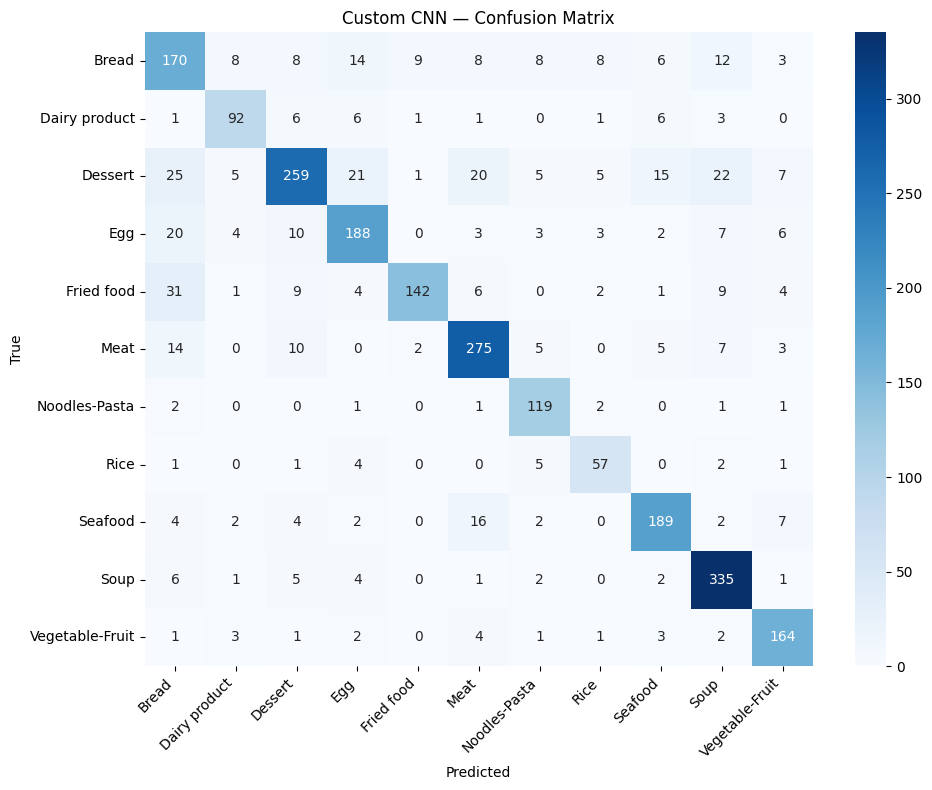

In [59]:
# cell 10 — evaluate custom CNN (skip plot_history since we loaded weights)

def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['accuracy'], label='Train Accuracy')
    ax1.plot(history['val_accuracy'], label='Val Accuracy')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history['loss'], label='Train Loss')
    ax2.plot(history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

@torch.no_grad()
def full_evaluate(model, loader, class_names, title="", device=DEVICE):
    """Full evaluation: accuracy, classification report, confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss, total = 0.0, 0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        total += labels.size(0)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    avg_loss = total_loss / total

    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"  Test Loss: {avg_loss:.4f}  |  Test Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()
    return avg_loss, acc

# plot_history(cnn_history, "Custom CNN (No Augmentation)")  # skipped — no training history
cnn_loss, cnn_acc = full_evaluate(cnn_model, test_loader, CLASS_NAMES, "Custom CNN")

In [60]:
# cell 12 — build MobileNetV2 transfer learning model

def build_mobilenet(num_classes=NUM_CLASSES, freeze=True):
    model = models.mobilenet_v2(weights='IMAGENET1K_V1')

    if freeze:
        for param in model.features.parameters():
            param.requires_grad = False

    # replace classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.last_channel, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model

tl_model = build_mobilenet(NUM_CLASSES, freeze=True).to(DEVICE)

total_params = sum(p.numel() for p in tl_model.parameters())
trainable_params = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f"MobileNetV2 — Total: {total_params:,} | Trainable: {trainable_params:,} (base frozen)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\limsh/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 12.4MB/s]


MobileNetV2 — Total: 2,555,147 | Trainable: 331,275 (base frozen)


In [ ]:
# cell 13 — train MobileNetV2 (frozen base)
# SKIP: loading pre-trained weights from cell 13b instead
# tl_history = train_model(tl_model, train_loader_base, val_loader, epochs=EPOCHS, lr=0.001, save_path=MODEL_DIR + "mobilenet_frozen.pth")

In [ ]:
# cell 13b — load saved MobileNetV2 frozen base weights

tl_model.load_state_dict(torch.load(MODEL_DIR + "mobilenet_frozen.pth", map_location=DEVICE))
tl_model.eval()
print("Loaded mobilenet_frozen.pth")

In [ ]:
# cell 14 — fine-tune MobileNetV2 (unfreeze last few feature blocks)
# SKIP: loading pre-trained weights from cell 14b instead
# for param in tl_model.features[14:].parameters():
#     param.requires_grad = True
# trainable_now = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
# print(f"Trainable params after unfreezing: {trainable_now:,}")
# tl_history_ft = train_model(tl_model, train_loader_base, val_loader, epochs=15, lr=1e-4, patience=5, save_path=MODEL_DIR + "mobilenet_finetuned.pth")

In [ ]:
# cell 14b — load saved fine-tuned MobileNetV2 weights

tl_model = build_mobilenet(NUM_CLASSES, freeze=False).to(DEVICE)
tl_model.load_state_dict(torch.load(MODEL_DIR + "mobilenet_finetuned.pth", map_location=DEVICE))
tl_model.eval()
print("Loaded mobilenet_finetuned.pth")

In [ ]:
# cell 15 — plot transfer learning training curves
# SKIP: no training history available (loaded weights from file)
# plot_history(tl_history, "MobileNetV2 (Frozen Base)")
# plot_history(tl_history_ft, "MobileNetV2 (Fine-Tuned)")
print("Skipped — training curves not available when loading saved weights")

In [ ]:
# cell 16 — evaluate MobileNetV2 on test set

tl_loss, tl_acc = full_evaluate(tl_model, test_loader, CLASS_NAMES, "MobileNetV2 (Fine-Tuned)")

In [ ]:
# cell 18 — retrain custom CNN WITH data augmentation
# SKIP: loading pre-trained weights from cell 18b instead
# cnn_model_aug = FoodCNN(NUM_CLASSES).to(DEVICE)
# cnn_aug_history = train_model(cnn_model_aug, train_loader_aug, val_loader, epochs=EPOCHS, lr=0.001, save_path=MODEL_DIR + "cnn_model_aug.pth")
# plot_history(cnn_aug_history, "Custom CNN (With Augmentation)")

In [ ]:
# cell 18b — load saved augmented CNN weights

cnn_model_aug = FoodCNN(NUM_CLASSES).to(DEVICE)
cnn_model_aug.load_state_dict(torch.load(MODEL_DIR + "cnn_model_aug.pth", map_location=DEVICE))
cnn_model_aug.eval()
print("Loaded cnn_model_aug.pth")

cnn_aug_loss, cnn_aug_acc = full_evaluate(cnn_model_aug, test_loader, CLASS_NAMES, "Custom CNN (Augmented)")

In [ ]:
# cell 19 — retrain MobileNetV2 WITH data augmentation
# SKIP: loading pre-trained weights from cell 19b instead
# tl_model_aug = build_mobilenet(NUM_CLASSES, freeze=True).to(DEVICE)
# tl_aug_history = train_model(tl_model_aug, train_loader_aug, val_loader, epochs=EPOCHS, lr=0.001, save_path=MODEL_DIR + "mobilenet_aug_frozen.pth")
# for param in tl_model_aug.features[14:].parameters():
#     param.requires_grad = True
# tl_aug_ft_history = train_model(tl_model_aug, train_loader_aug, val_loader, epochs=15, lr=1e-4, patience=5, save_path=MODEL_DIR + "mobilenet_aug_finetuned.pth")
# plot_history(tl_aug_ft_history, "MobileNetV2 + Augmentation (Fine-Tuned)")

In [ ]:
# cell 19b — load saved augmented MobileNetV2 weights

tl_model_aug = build_mobilenet(NUM_CLASSES, freeze=False).to(DEVICE)
tl_model_aug.load_state_dict(torch.load(MODEL_DIR + "mobilenet_aug_finetuned.pth", map_location=DEVICE))
tl_model_aug.eval()
print("Loaded mobilenet_aug_finetuned.pth")

tl_aug_loss, tl_aug_acc = full_evaluate(tl_model_aug, test_loader, CLASS_NAMES, "MobileNetV2 (Augmented + Fine-Tuned)")

In [ ]:
# cell 21 — compare all 4 models side by side

import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Custom CNN (No Aug)',
        'Custom CNN (With Aug)',
        'MobileNetV2 (No Aug)',
        'MobileNetV2 (With Aug)'
    ],
    'Test Loss': [cnn_loss, cnn_aug_loss, tl_loss, tl_aug_loss],
    'Test Accuracy': [cnn_acc, cnn_aug_acc, tl_acc, tl_aug_acc]
})

print(results.to_string(index=False))

# bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#64B5F6', '#FF5722', '#FF8A65']

ax1.barh(results['Model'], results['Test Accuracy'], color=colors)
ax1.set_xlabel('Accuracy')
ax1.set_title('Test Accuracy Comparison')
ax1.set_xlim(0, 1)
for i, v in enumerate(results['Test Accuracy']):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center')

ax2.barh(results['Model'], results['Test Loss'], color=colors)
ax2.set_xlabel('Loss')
ax2.set_title('Test Loss Comparison')
for i, v in enumerate(results['Test Loss']):
    ax2.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# cell 23 — external test: in-category images

ext_in_dir = EXTERNAL_DIR + "in_category/"

ext_dataset = datasets.ImageFolder(ext_in_dir, transform=transform_base)
ext_loader = DataLoader(ext_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

ext_class_names = ext_dataset.classes
print(f"External in-category images: {len(ext_dataset)}")
print(f"Classes found: {ext_class_names}")

print("\n" + "="*60)
print("EXTERNAL IN-CATEGORY EVALUATION")
print("="*60)

cnn_ext_loss, cnn_ext_acc = full_evaluate(cnn_model, ext_loader, ext_class_names, "Custom CNN (External)")
tl_ext_loss, tl_ext_acc = full_evaluate(tl_model, ext_loader, ext_class_names, "MobileNetV2 (External)")

In [ ]:
# cell 24 — external test: out-of-category images (misclassification analysis)

ext_out_dir = EXTERNAL_DIR + "out_of_category/"
ext_out_path = pathlib.Path(ext_out_dir)
out_images = sorted([f for f in ext_out_path.rglob("*") if f.suffix.lower() in ('.jpg', '.jpeg', '.png', '.webp')])

print(f"Out-of-category images found: {len(out_images)}")

best_model = tl_model if tl_ext_acc >= cnn_ext_acc else cnn_model
best_name = "MobileNetV2" if tl_ext_acc >= cnn_ext_acc else "Custom CNN"
best_model.eval()

predictions_oc = []
fig_cols = 5
fig_rows = max(1, (len(out_images) + fig_cols - 1) // fig_cols)
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(16, 3 * fig_rows))
axes = np.array(axes).flatten()

for i, img_path in enumerate(out_images):
    img = Image.open(str(img_path)).convert('RGB')
    img_tensor = transform_base(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = best_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, pred_idx = probs.max(1)

    pred_class = CLASS_NAMES[pred_idx.item()]
    conf = confidence.item()

    predictions_oc.append({
        'filename': img_path.name,
        'predicted_class': pred_class,
        'confidence': conf
    })

    if i < len(axes):
        axes[i].imshow(img.resize((IMG_SIZE, IMG_SIZE)))
        axes[i].set_title(f"{pred_class}\n({conf:.2f})", fontsize=9,
                          color='red' if conf > 0.5 else 'orange')
        axes[i].axis("off")

for j in range(len(out_images), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Out-of-Category Predictions — {best_name}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

oc_df = pd.DataFrame(predictions_oc)
print("\nOut-of-Category Prediction Results:")
print(oc_df.to_string(index=False))
print(f"\nAverage confidence on out-of-category: {oc_df['confidence'].mean():.4f}")
print(f"Images predicted with high confidence (>0.8): {(oc_df['confidence'] > 0.8).sum()}/{len(oc_df)}")

In [ ]:
# cell 25 — final summary table (all experiments)

print("="*70)
print("  FINAL MODEL COMPARISON SUMMARY")
print("="*70)

summary = pd.DataFrame({
    'Model': [
        'Custom CNN',
        'Custom CNN + Aug',
        'MobileNetV2 (Fine-Tuned)',
        'MobileNetV2 + Aug (Fine-Tuned)'
    ],
    'Test Acc': [f'{cnn_acc:.4f}', f'{cnn_aug_acc:.4f}', f'{tl_acc:.4f}', f'{tl_aug_acc:.4f}'],
    'Test Loss': [f'{cnn_loss:.4f}', f'{cnn_aug_loss:.4f}', f'{tl_loss:.4f}', f'{tl_aug_loss:.4f}'],
    'Ext Acc': [f'{cnn_ext_acc:.4f}', '—', f'{tl_ext_acc:.4f}', '—'],
})

print(summary.to_string(index=False))

print("\n\nKey Observations:")
print("-" * 40)
if tl_acc > cnn_acc:
    print(f"• MobileNetV2 outperforms Custom CNN by {(tl_acc - cnn_acc)*100:.1f}% on test set")
else:
    print(f"• Custom CNN outperforms MobileNetV2 by {(cnn_acc - tl_acc)*100:.1f}% on test set")

if cnn_aug_acc > cnn_acc:
    print(f"• Data augmentation improved Custom CNN by {(cnn_aug_acc - cnn_acc)*100:.1f}%")
else:
    print(f"• Data augmentation did not improve Custom CNN ({(cnn_aug_acc - cnn_acc)*100:.1f}%)")

if tl_aug_acc > tl_acc:
    print(f"• Data augmentation improved MobileNetV2 by {(tl_aug_acc - tl_acc)*100:.1f}%")
else:
    print(f"• Data augmentation had minimal effect on MobileNetV2 ({(tl_aug_acc - tl_acc)*100:.1f}%)")

print(f"\n• Best model: {'MobileNetV2' if max(tl_acc, tl_aug_acc) >= max(cnn_acc, cnn_aug_acc) else 'Custom CNN'}")
print(f"  with test accuracy: {max(cnn_acc, cnn_aug_acc, tl_acc, tl_aug_acc):.4f}")